# Introduction
Predicting customer churn is critical for telecommunication companies to be able to effectively retain customers. It is more costly to acquire new customers than to retain existing ones.
The Telco customer churn data contains information about a fictional telco company that provided home phone and internet
service to 7043 customers in california. It indicates which customers have left, stayed, or signed up for their service.
Multiple important demographics are included for each customer, as well as a satisfaction score and churn score.
The dataset has various columns which are;

1. CUSTOMERID: A unique ID that identifies each customer 
2. GENDER: The customer's gender: Male, Female
3. SENIORCITIZEN: Whether the client is a senior citizen or not
4. PARTNER: Whether the client has a partner or not
5. DEPENDENTS: Whether the client has dependents or not
6. TENURE: Number of months customer has stayed with the company (multiple different numeric values)
7. PHONESERVICE: Whether the client has a phone service or not
6. MULTIPLELINES: Whether the client has a phone service or not(yes or no)
7. INTERNETSERVICE: Whether the client is subscribed to internet service with the company(DSL, Fiber optic, No)
8. ONLINESECURITY: Whether the client has online security or not
9. ONLINEBACKUP: Whether the client has online backup or not
10. DEVICEPROTECTION: Whether the client has device protection or not
11. TECHSUPPORT: Whether the client has tech support or not
12. STREAMINGTV: Whether the client has streaming tv or not 
13. STREAMINGMOVIES: Whether the client has streaming movies or not
14. CONTRACT: Indicates the customer's current contract type
15. PAPERLESSBILLING: Whether the client has paperlessbilling or not
16. PAYMENTMETHOD: The customer's payment method(electronic check, mailed check, bank transfer,(automatic), credit card(automatic)).
17. MONTHLYCHARGES: The amount charges to the customer monthly (multiple different numeric values)
18. TOTALCHARGES: The total amount charged to the customer(multiple different numeric values)
19. CHURN: Whether the customer is retained or left 
# 

# AIM AND OBJECTIVE
The aim of this project is to develop models to predict which customers are more likely to change and take actions accordingly by analyzing its characteristicss such as the demographic information, account information and services information. 
The objective is to obtain a data driven solution that will allow us to reduce churn rates and, as a consequence, to increase customer satisfaction and corporation revenue.

#  STEPS INVOLVED IN THE PROJECT 

1. Data Reading
2. Exploratory Data Analysis
3. Data Visualization
4. Feature Engineeering
5. Splitting the dataset in training and testing sets
6. Acessing multiple algorithms
7. Checking accuracy and performance of model
8. Making predictive system 
9. Drawing conclusions - summary

In [1]:
#importing libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import accuracy_score
from sklearn import datasets, linear_model, model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
print(df)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [25]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
df.shape

(7043, 21)

 The data contains 7043 rows and 21 columns respectively

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

# Statistical Measures

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df1 = df.copy()

In [11]:
df1.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
#converting all the columns to small letters
df1.columns = df1.columns.str.lower() 
df1.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [13]:
#checking the head of the data again
df1.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
#checking the datatypes
df1.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges         object
churn                object
dtype: object

# Label Encoding

 renaming yes as 1, No as 0 and 2 as No internet Service

In [15]:
df1 = df1.replace('Yes', 1)
df1 = df1.replace('No', 0)
df1 = df1.replace('No internet service', 2)
df1 = df1.replace('No phone service', 2)

In [16]:
df1.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,1,0,1,0,2,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,2,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [17]:
#checking the datatypes again
df1.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner               int64
dependents            int64
tenure                int64
phoneservice          int64
multiplelines         int64
internetservice      object
onlinesecurity        int64
onlinebackup          int64
deviceprotection      int64
techsupport           int64
streamingtv           int64
streamingmovies       int64
contract             object
paperlessbilling      int64
paymentmethod        object
monthlycharges      float64
totalcharges         object
churn                 int64
dtype: object

In [18]:
#checking fro null values 
df1.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [27]:
df1[df1['totalcharges'].isnull()]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
488,4472-LVYGI,Female,0,1,1,0,0,2,DSL,1,...,1,1,1,0,Two year,1,Bank transfer (automatic),52.55,NaN,0
753,3115-CZMZD,Male,0,0,1,0,1,0,0,2,...,2,2,2,2,Two year,0,Mailed check,20.25,NaN,0
936,5709-LVOEQ,Female,0,1,1,0,1,0,DSL,1,...,1,0,1,1,Two year,0,Mailed check,80.85,NaN,0
1082,4367-NUYAO,Male,0,1,1,0,1,1,0,2,...,2,2,2,2,Two year,0,Mailed check,25.75,NaN,0
1340,1371-DWPAZ,Female,0,1,1,0,0,2,DSL,1,...,1,1,1,0,Two year,0,Credit card (automatic),56.05,NaN,0
3331,7644-OMVMY,Male,0,1,1,0,1,0,0,2,...,2,2,2,2,Two year,0,Mailed check,19.85,NaN,0
3826,3213-VVOLG,Male,0,1,1,0,1,1,0,2,...,2,2,2,2,Two year,0,Mailed check,25.35,NaN,0
4380,2520-SGTTA,Female,0,1,1,0,1,0,0,2,...,2,2,2,2,Two year,0,Mailed check,20.00,NaN,0
5218,2923-ARZLG,Male,0,1,1,0,1,0,0,2,...,2,2,2,2,One year,1,Mailed check,19.70,NaN,0
6670,4075-WKNIU,Female,0,1,1,0,1,1,DSL,0,...,1,1,1,0,Two year,0,Mailed check,73.35,NaN,0


In [28]:
#dropping the empty rows present 
df1.dropna(inplace=True)

In [29]:
#rechecking again
df1[df1['totalcharges'].isnull()]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn


In [30]:
#converting totalcharges column from obeject to integers
df1['totalcharges'] = pd.to_numeric(df1['totalcharges'], errors='coerce')

In [31]:
df1.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner               int64
dependents            int64
tenure                int64
phoneservice          int64
multiplelines         int64
internetservice      object
onlinesecurity        int64
onlinebackup          int64
deviceprotection      int64
techsupport           int64
streamingtv           int64
streamingmovies       int64
contract             object
paperlessbilling      int64
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

In [32]:
convert_charges = {
                'monthlycharges' : int,
                'totalcharges': int,
        
            
}
df1 = df1.astype(convert_charges)

In [33]:
#rechecking the datatypes again 
df1.dtypes

customerid          object
gender              object
seniorcitizen        int64
partner              int64
dependents           int64
tenure               int64
phoneservice         int64
multiplelines        int64
internetservice     object
onlinesecurity       int64
onlinebackup         int64
deviceprotection     int64
techsupport          int64
streamingtv          int64
streamingmovies      int64
contract            object
paperlessbilling     int64
paymentmethod       object
monthlycharges       int32
totalcharges         int32
churn                int64
dtype: object

# Data Visualization

In [34]:
df1['gender'].value_counts()

Male      3549
Female    3483
Name: gender, dtype: int64

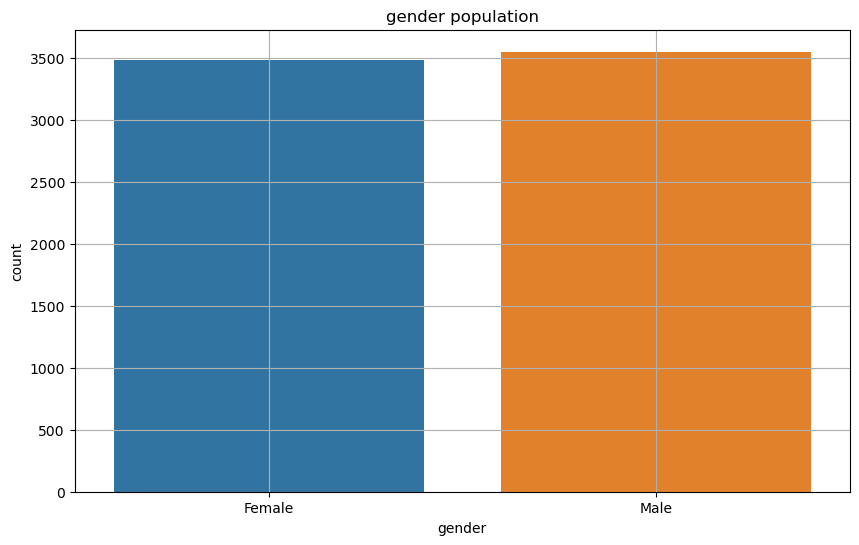

In [35]:
plt.figure(figsize=(10,6))
sns.countplot(x ='gender', data =df1)
plt.title("gender population")
plt.xticks(rotation = 0)
plt.grid()

In [36]:
df1['seniorcitizen'].value_counts()

0    5890
1    1142
Name: seniorcitizen, dtype: int64

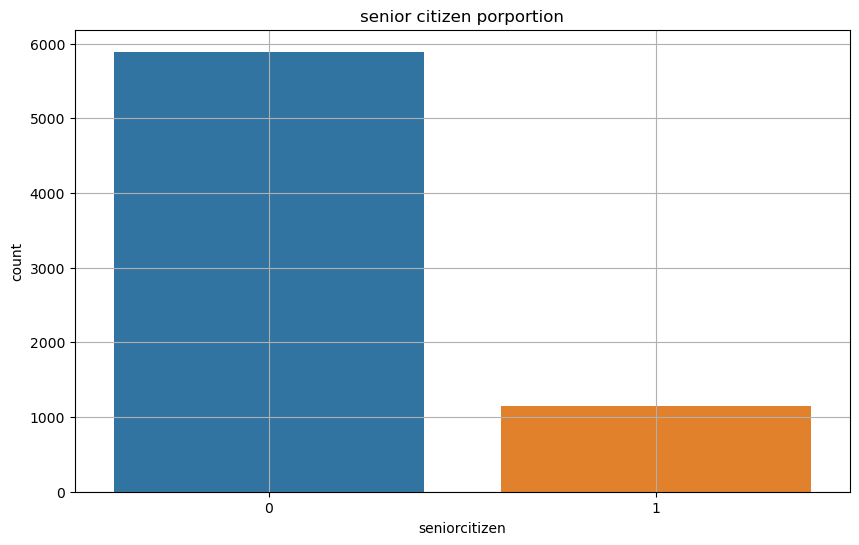

In [37]:
plt.figure(figsize=(10,6))
sns.countplot(x ='seniorcitizen', data =df1)
plt.title("senior citizen porportion")
plt.xticks(rotation = 0)
plt.grid()

In [38]:
df1['multiplelines'].value_counts()

0    3385
1    2967
2     680
Name: multiplelines, dtype: int64

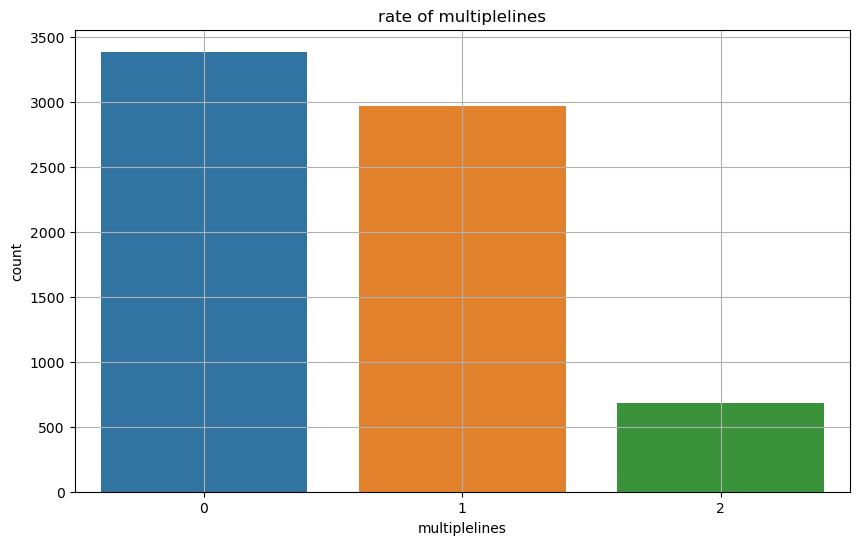

In [39]:
plt.figure(figsize=(10,6))
sns.countplot(x ='multiplelines', data =df1)
plt.title("rate of multiplelines")
plt.xticks(rotation = 0)
plt.grid()

In [40]:
df1['onlinesecurity'].value_counts()

0    3497
1    2015
2    1520
Name: onlinesecurity, dtype: int64

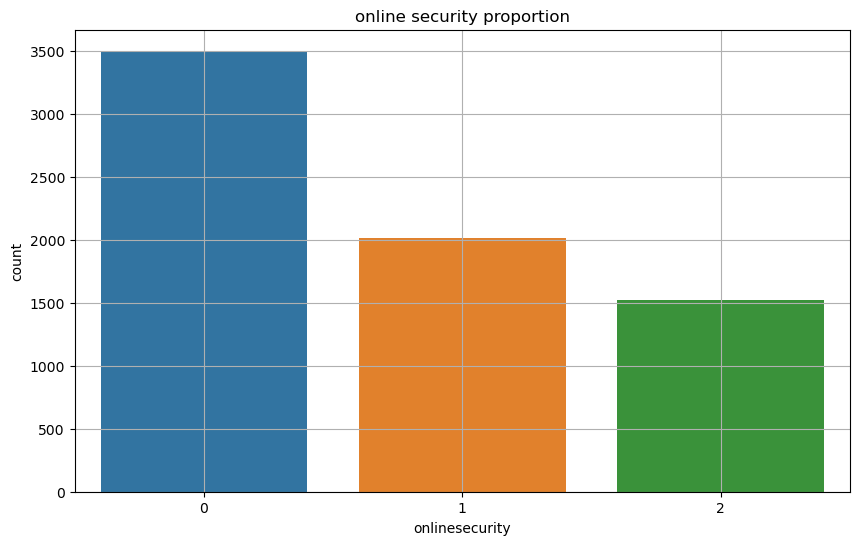

In [41]:
plt.figure(figsize=(10,6))
sns.countplot(x ='onlinesecurity', data =df1)
plt.title("online security proportion")
plt.xticks(rotation = 0)
plt.grid()

In [42]:
df1['deviceprotection'].value_counts()

0    3094
1    2418
2    1520
Name: deviceprotection, dtype: int64

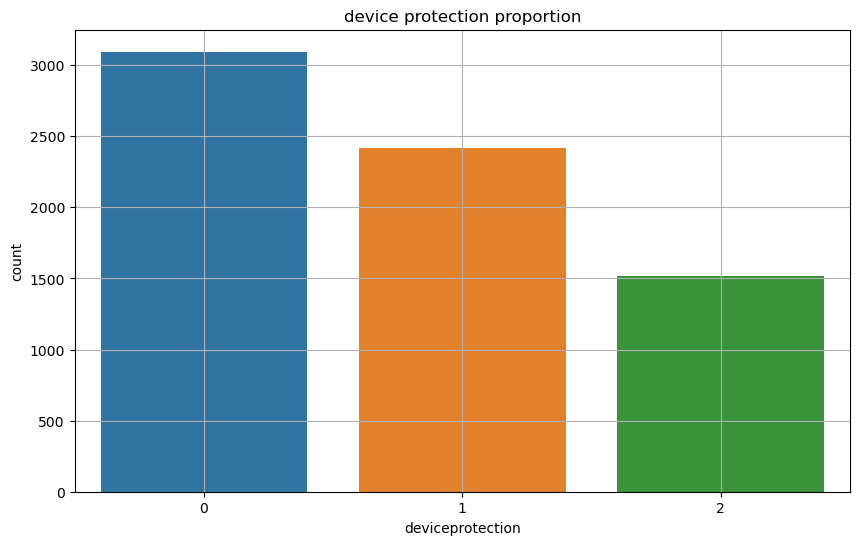

In [43]:
plt.figure(figsize=(10,6))
sns.countplot(x ='deviceprotection', data =df1)
plt.title("device protection proportion")
plt.xticks(rotation = 0)
plt.grid()

In [44]:
df1['techsupport'].value_counts()

0    3472
1    2040
2    1520
Name: techsupport, dtype: int64

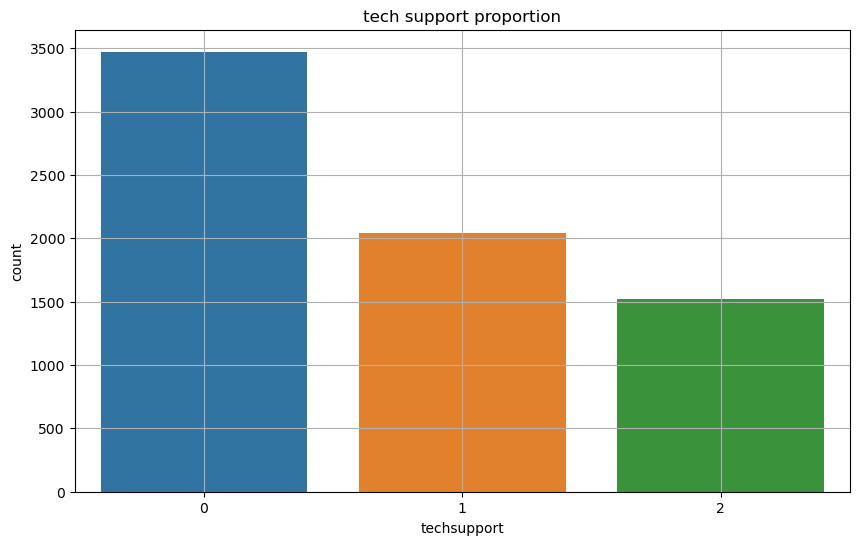

In [45]:
plt.figure(figsize=(10,6))
sns.countplot(x ='techsupport', data =df1)
plt.title("tech support proportion")
plt.xticks(rotation = 0)
plt.grid()

In [46]:
df1['streamingtv'].value_counts()

0    2809
1    2703
2    1520
Name: streamingtv, dtype: int64

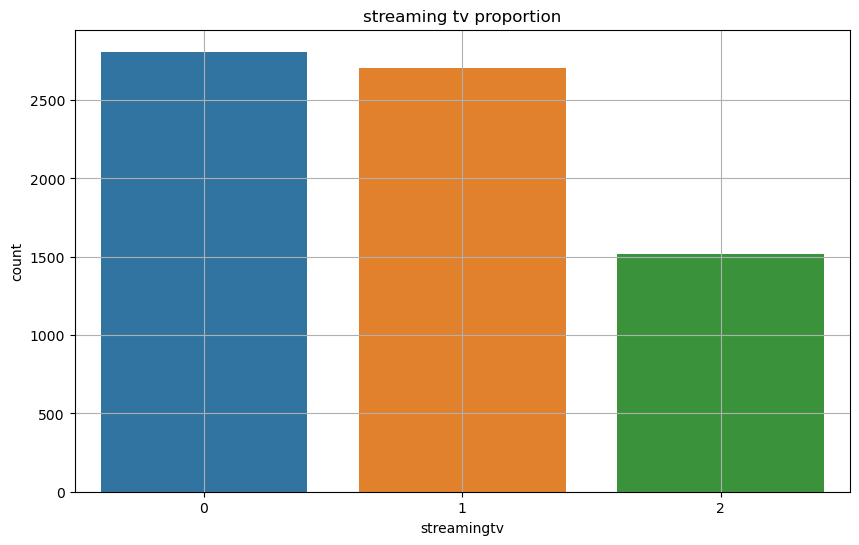

In [47]:
plt.figure(figsize=(10,6))
sns.countplot(x ='streamingtv', data =df1)
plt.title("streaming tv proportion")
plt.xticks(rotation = 0)
plt.grid()

In [48]:
df1['streamingmovies'].value_counts()

0    2781
1    2731
2    1520
Name: streamingmovies, dtype: int64

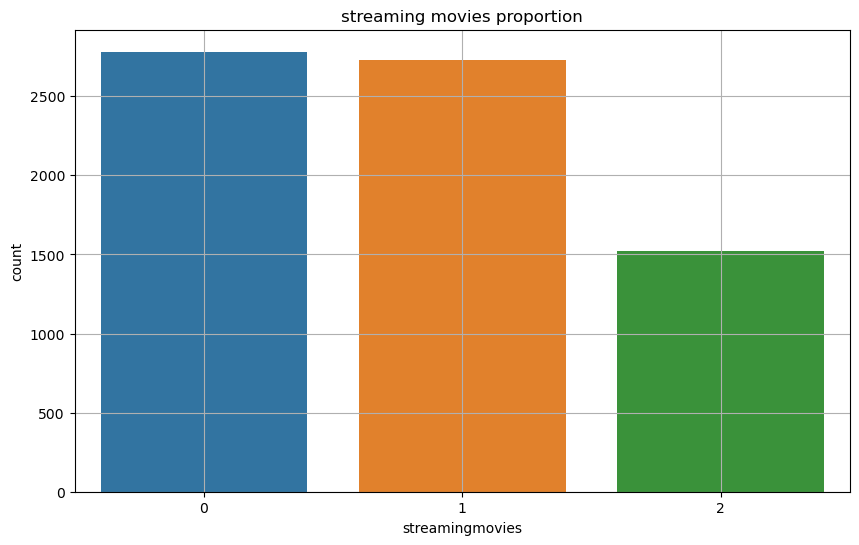

In [49]:
plt.figure(figsize=(10,6))
sns.countplot(x ='streamingmovies', data =df1)
plt.title("streaming movies proportion")
plt.xticks(rotation = 0)
plt.grid()

In [50]:
df1['onlinebackup'].value_counts()

0    3087
1    2425
2    1520
Name: onlinebackup, dtype: int64

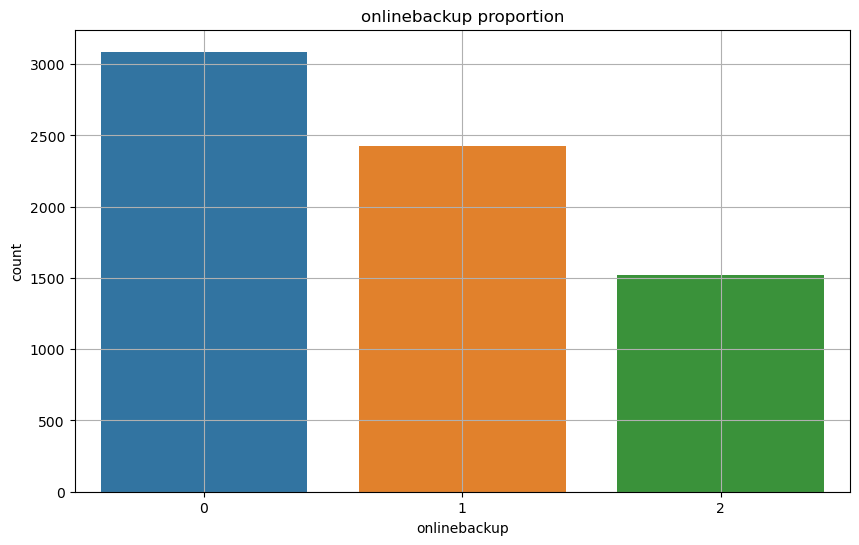

In [51]:
plt.figure(figsize=(10,6))
sns.countplot(x ='onlinebackup', data =df1)
plt.title("onlinebackup proportion")
plt.xticks(rotation = 0)
plt.grid()

In [52]:
df1['paperlessbilling'].value_counts

<bound method IndexOpsMixin.value_counts of 0       1
1       0
2       1
3       0
4       1
       ..
7038    1
7039    1
7040    1
7041    1
7042    1
Name: paperlessbilling, Length: 7032, dtype: int64>

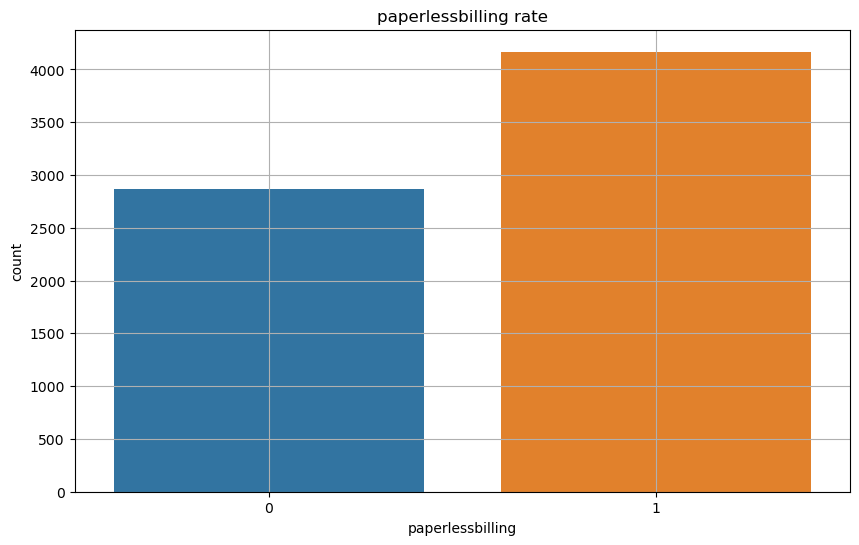

In [53]:
plt.figure(figsize=(10,6))
sns.countplot(x ='paperlessbilling', data =df1)
plt.title("paperlessbilling rate")
plt.xticks(rotation = 0)
plt.grid()

In [54]:
df1['partner'].value_counts()

0    3639
1    3393
Name: partner, dtype: int64

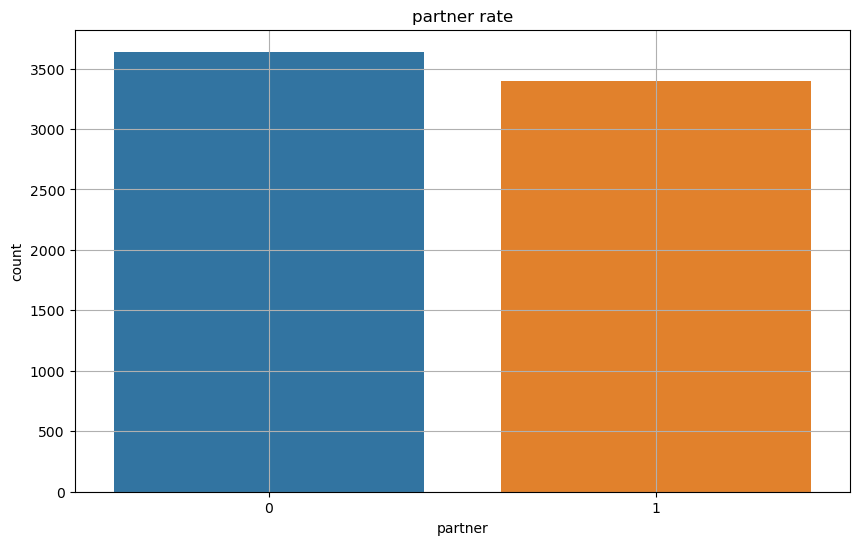

In [55]:
plt.figure(figsize=(10,6))
sns.countplot(x ='partner', data =df1)
plt.title("partner rate")
plt.xticks(rotation = 0)
plt.grid()

In [56]:
df1['dependents'].value_counts()

0    4933
1    2099
Name: dependents, dtype: int64

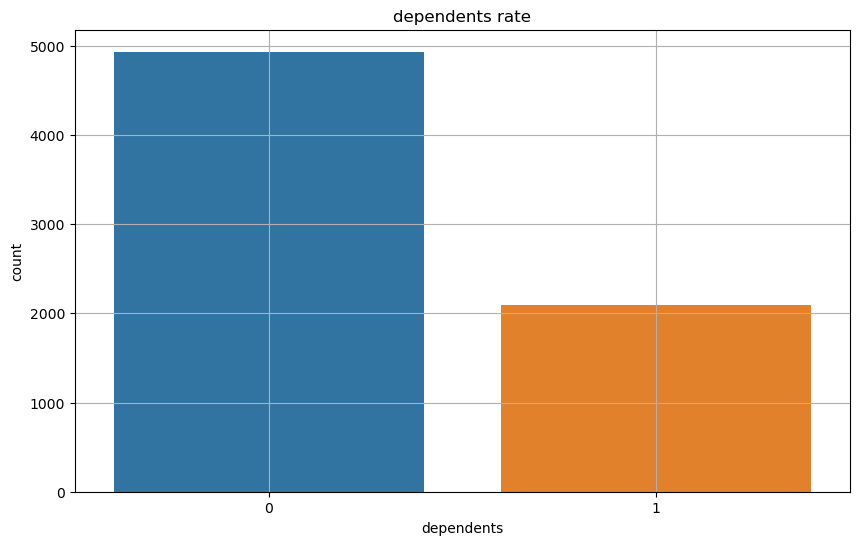

In [57]:
plt.figure(figsize=(10,6))
sns.countplot(x ='dependents', data =df1)
plt.title("dependents rate")
plt.xticks(rotation = 0)
plt.grid()

In [58]:
df1['phoneservice'].value_counts()

1    6352
0     680
Name: phoneservice, dtype: int64

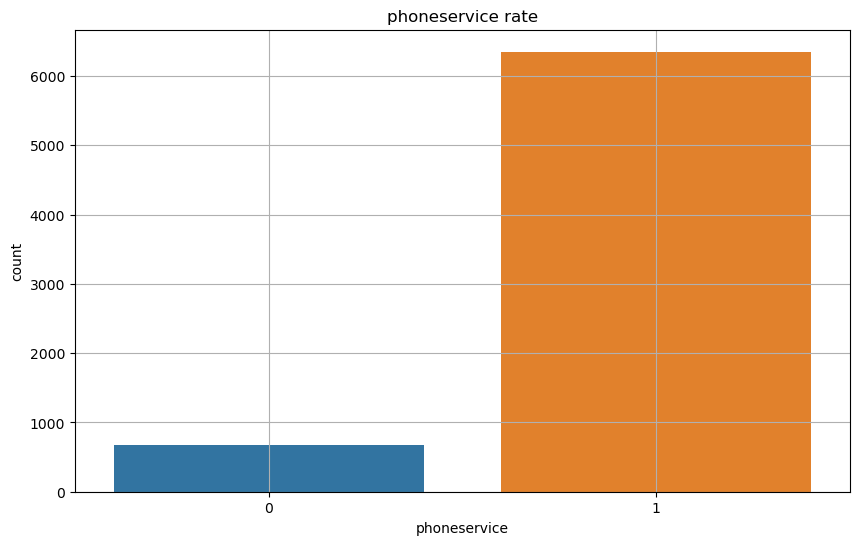

In [59]:
plt.figure(figsize=(10,6))
sns.countplot(x ='phoneservice', data =df1)
plt.title("phoneservice rate")
plt.xticks(rotation = 0)
plt.grid()

In [60]:
df1['internetservice'].value_counts()

Fiber optic    3096
DSL            2416
0              1520
Name: internetservice, dtype: int64

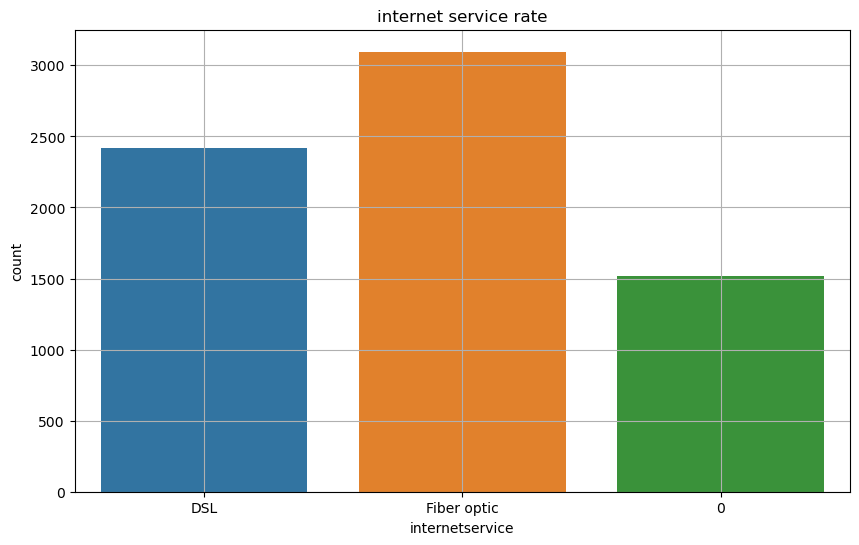

In [61]:
plt.figure(figsize=(10,6))
sns.countplot(x ='internetservice', data =df1)
plt.title("internet service rate")
plt.xticks(rotation = 0)
plt.grid()

In [62]:
df1['churn'].value_counts()

0    5163
1    1869
Name: churn, dtype: int64

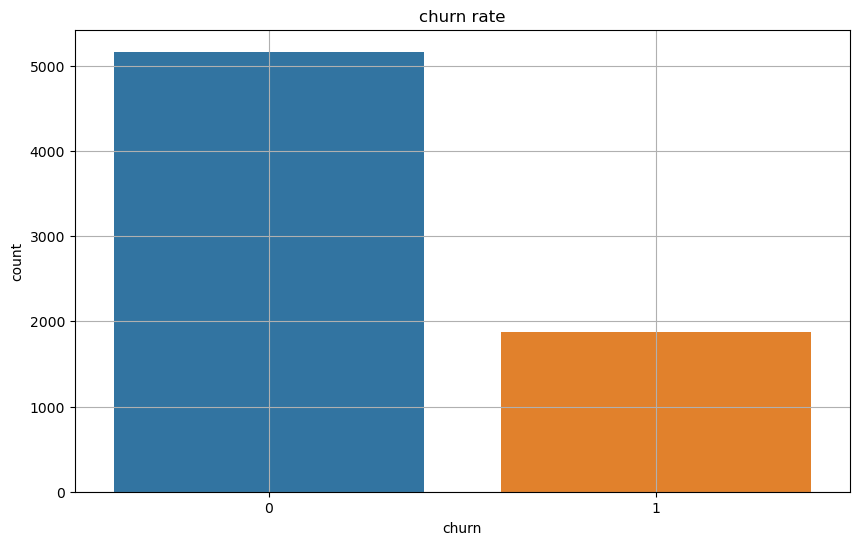

In [63]:
plt.figure(figsize=(10,6))
sns.countplot(x ='churn', data =df1)
plt.title("churn rate")
plt.xticks(rotation = 0)
plt.grid()

# Multivariate Analysis

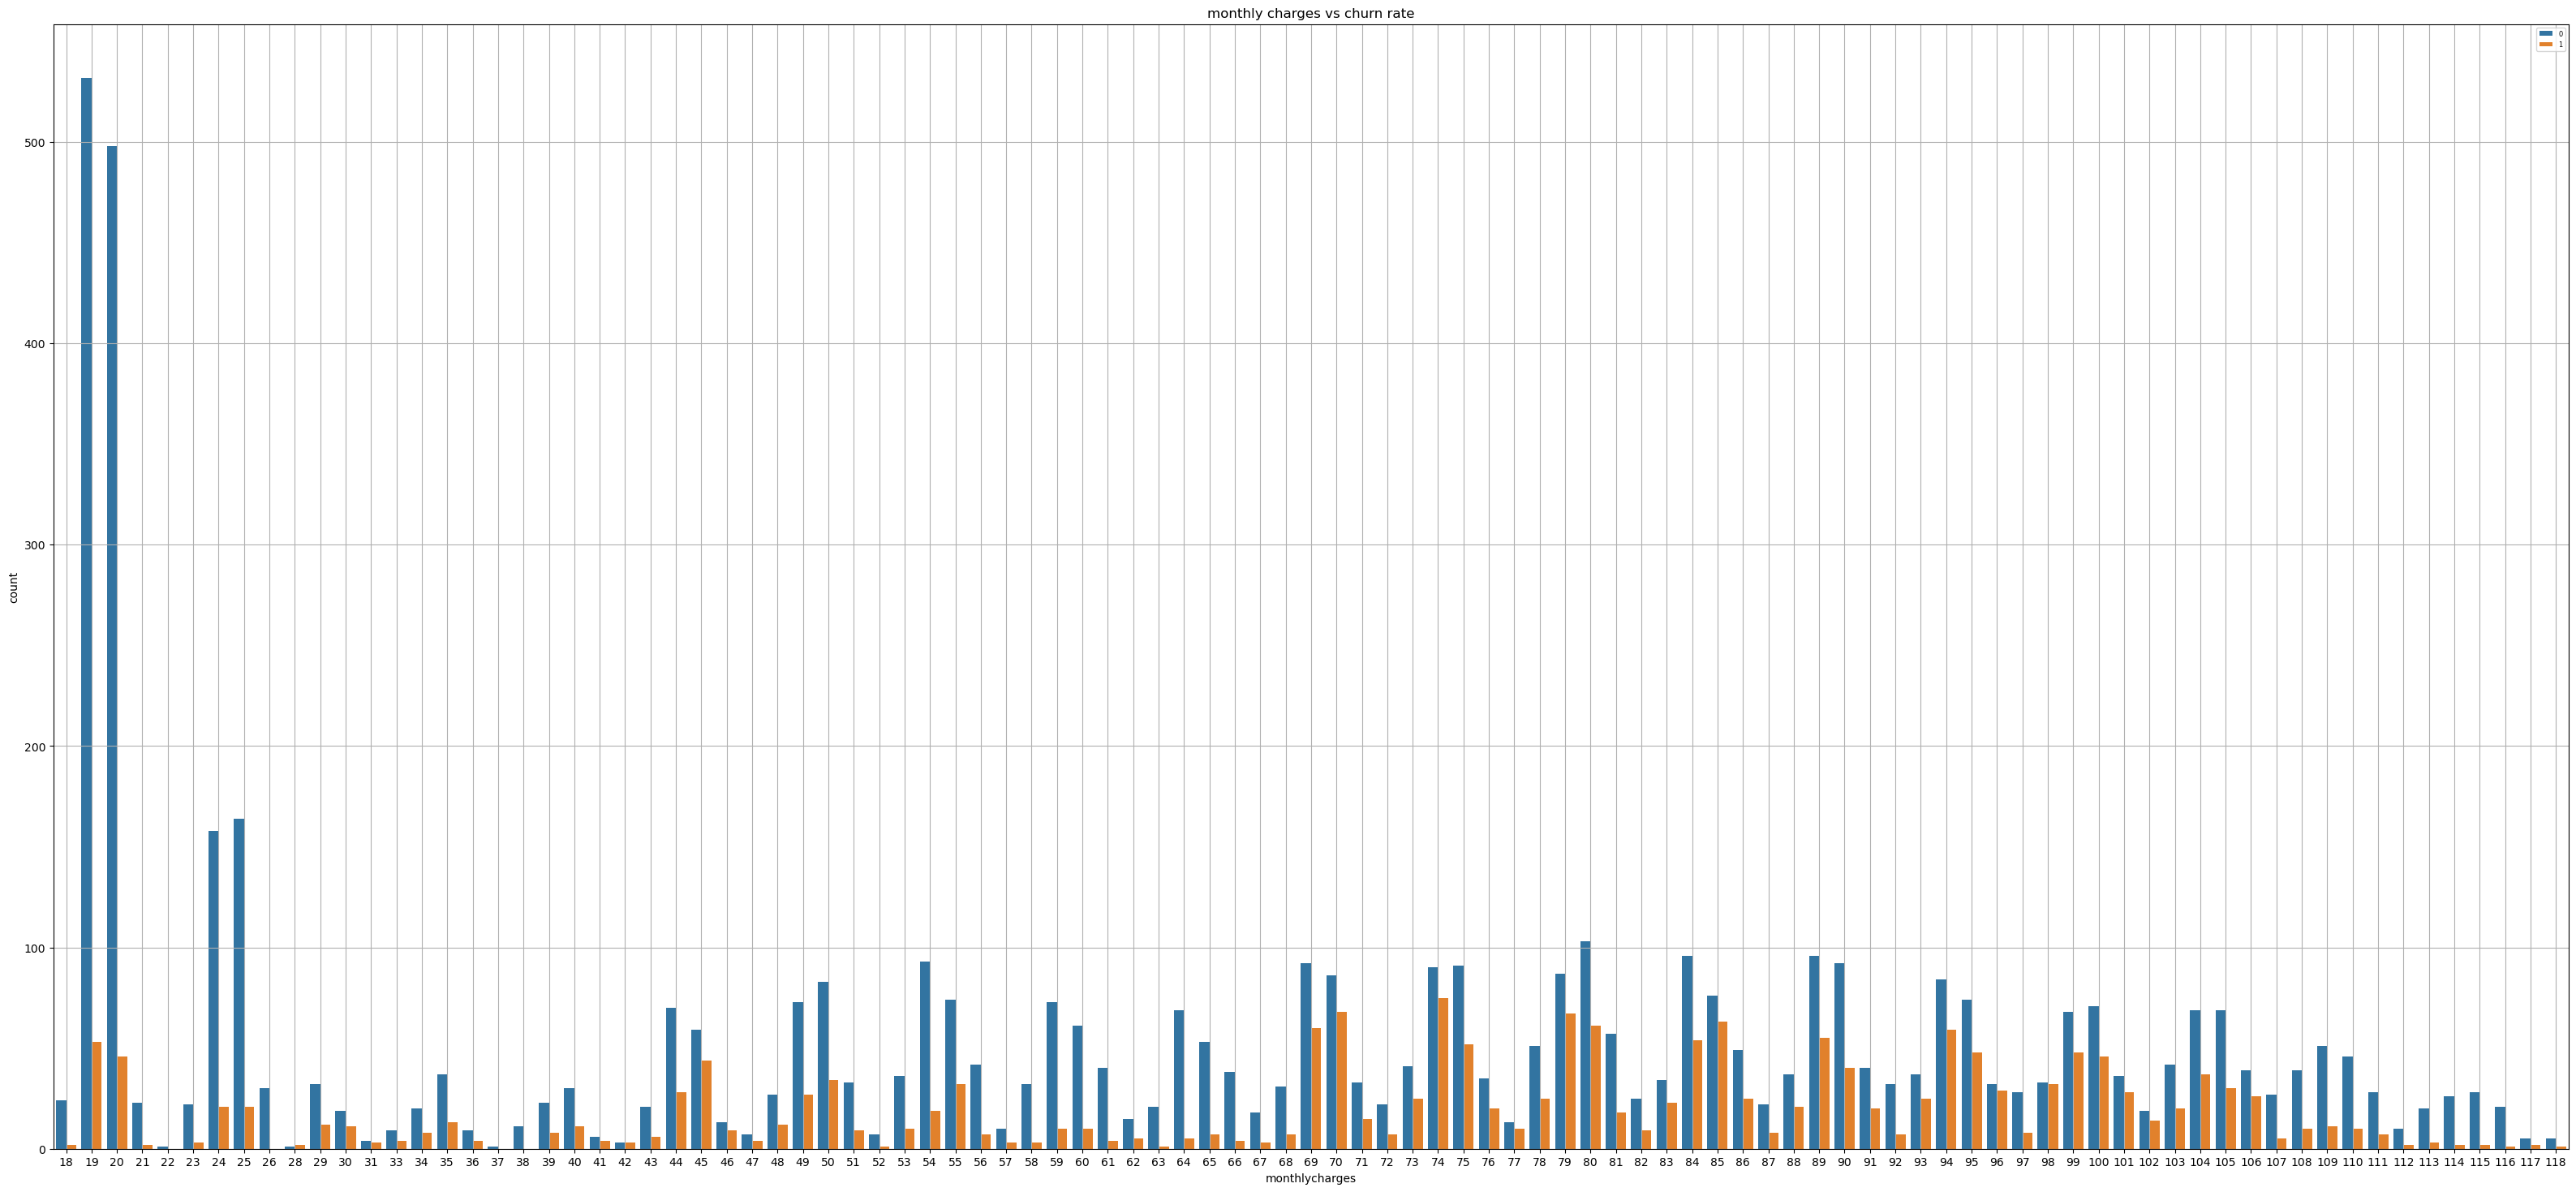

In [64]:
#conducting a bivariate and multivariate analysis
plt.figure(figsize=(40,18))
sns.countplot(x = 'monthlycharges', hue = 'churn', data = df1)
plt.title("monthly charges vs churn rate")
plt.legend(fontsize=6)
plt.grid()

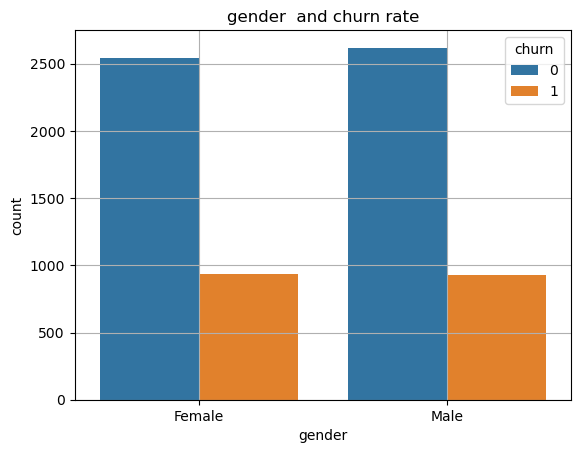

In [65]:
sns.countplot(x = 'gender', hue = 'churn', data = df1).set(title="gender  and churn rate")
plt.grid()

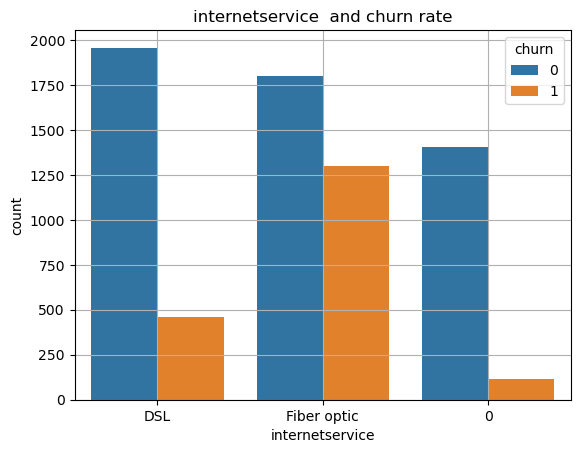

In [66]:
# internetservice  and churn rate
sns.countplot(x = "internetservice", hue= "churn", data = df1).set(title="internetservice  and churn rate")
plt.grid()

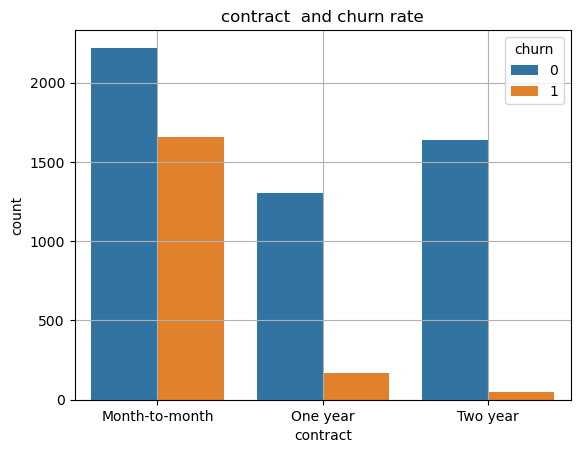

In [67]:
# contract  and churn rate
sns.countplot(x = "contract", hue= "churn", data = df1).set(title="contract  and churn rate")
plt.grid()

 Note: 0 represents month to month, 1 represents one year while 2 represent 2 years 

In [68]:
df1['paymentmethod'].value_counts()

Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: paymentmethod, dtype: int64

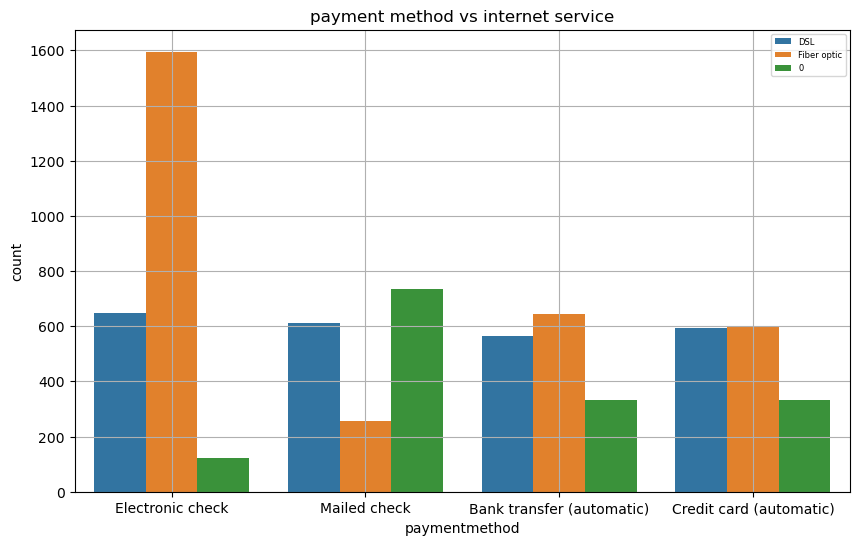

In [69]:
#conducting a bivariate and multivariate analysis
plt.figure(figsize=(10,6))
sns.countplot(x = 'paymentmethod', hue = 'internetservice', data = df1)
plt.title("payment method vs internet service")
plt.legend(fontsize=6)
plt.grid()

# Observation
Here, customers made use of the elctronic check compared to other mode of payment
present and the least mode of payment made is the credit card(automatic)

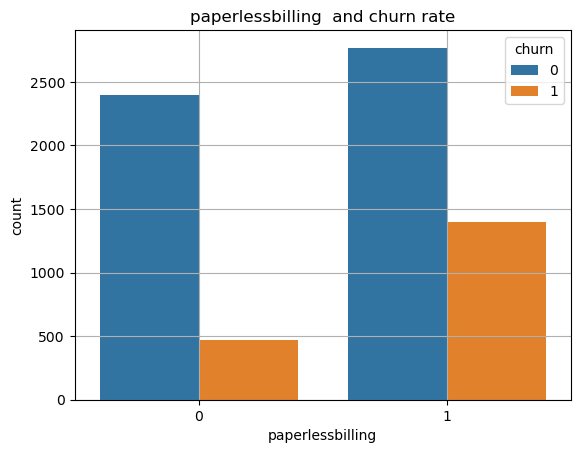

In [70]:
sns.countplot(x = 'paperlessbilling', hue = 'churn', data = df1).set(title="paperlessbilling  and churn rate")
plt.grid()

ValueError: hist method requires numerical or datetime columns, nothing to plot.

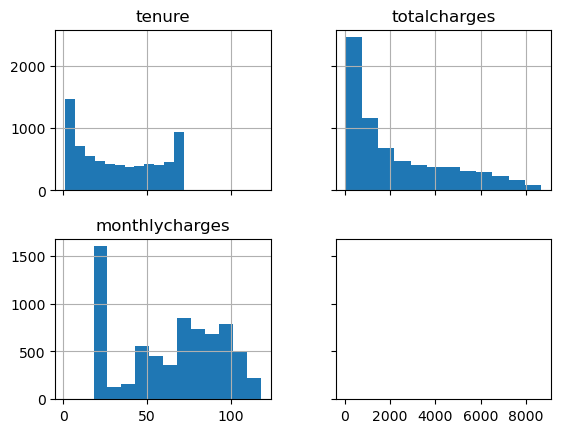

In [71]:
#histplot to show the distribution of customer account
fig, ax = plt.subplots(2, 2, sharex='col', sharey='row')
df2 = pd.DataFrame({'tenure':np.random.randn(100),
                   'totalcharges':np.random.randn(100),
                   'monthlycharges':np.random.randn(100),
                   'contract':np.random.randn(100)})
m = 0
for i in range(2):
    for j in range(2):
        df1.hist(column = df2.columns[m], bins = 12, ax=ax[i, j], figsize=(20,18))
        m+=1

# converting categorical columns to numerical

for gender, internetservice, contract, paymentmethod
This encoding replaces every category with a numerical label

In [ ]:
df1['internetservice'].unique()

In [72]:
df1['internetservice'].value_counts()

Fiber optic    3096
DSL            2416
0              1520
Name: internetservice, dtype: int64

In [73]:
df1['contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [74]:
df1['paymentmethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [75]:
#df1.replace(("gender":('Male':1, 'Female':0),'internetservice':('Fiber optic':1, 'DSL':2) ))

df1 = df1.replace({'gender':{'Male': 1, 'Female': 0}, 'internetservice':{'Fiber optic': 1, 'DSL':2, 'No': 0},
                  'contract':{'Month-to-month': 0, 'One year':1, 'Two year':2},
                  'paymentmethod':{'Electronic check': 0, 'Mailed check':1, 'Bank transfer (automatic)':2, 
                                   'Credit card (automatic)': 3 }})
df1.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,0,0,1,0,1,0,2,2,0,...,0,0,0,0,0,1,0,29,29,0
1,5575-GNVDE,1,0,0,0,34,1,0,2,1,...,1,0,0,0,1,0,1,56,1889,0
2,3668-QPYBK,1,0,0,0,2,1,0,2,1,...,0,0,0,0,0,1,1,53,108,1
3,7795-CFOCW,1,0,0,0,45,0,2,2,1,...,1,1,0,0,1,0,2,42,1840,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,0,70,151,1


In [76]:
df1.dtypes

customerid          object
gender               int64
seniorcitizen        int64
partner              int64
dependents           int64
tenure               int64
phoneservice         int64
multiplelines        int64
internetservice      int64
onlinesecurity       int64
onlinebackup         int64
deviceprotection     int64
techsupport          int64
streamingtv          int64
streamingmovies      int64
contract             int64
paperlessbilling     int64
paymentmethod        int64
monthlycharges       int32
totalcharges         int32
churn                int64
dtype: object

  # Insights from the EDA
EDA consists of analysing the main characteristics of a dataset usually by means of visualization method and summary statistics
The demographic information are the gender, seniorcitizen, partner and dependents.
Services which the customer has signed up for are;
phoneservice, multiplelines, internetservice, onlinesecurity, onlinebackup, deviceprotection, techsupport, streamtv and stream movies. 
from the demographic data, the visualization shows that the male customers are more than the female customers 
for senior citizen proportion, customer that are not senior citizen are more than customer that are senior citizens. 
for partner, customer that has no partner are a bit more than customer with partner
for dependents, customer that are not dependent are more than customer that are dependent.
The churn rate expectation was high, customers that left are more than those that are retained.
# Services rendered
In terms of streaming tv, streaming movies , online backup and tech support for either having internet services or not; it was showed that customers that have nothing are more than those with internet and no internet services.
paperless billing: customers with no paperless billing are less than custoemr with paperless billing 
Customers with no online security churn much more than customers with online security.
Customers with month - month has more churn rate(i.e it tends to be higher when monthly charges are high)
New customers (low tenure) are more likely to churn.
Clients with high total charges are less likely to leave the company.
There are also more churn rate in paperless billing.
The male gender shows less churn rate compared to the female gender. 

In [77]:
df1.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

# Preparing data for modelling 

In [78]:
#separating the data and the label

x = df1.drop(columns=['customerid', 'churn'], axis = 1)
y = df1['churn']

In [79]:
df1.shape

(7032, 21)

In [80]:
x1 = df1.iloc[:, [2,20]].values
y1 = df1.iloc[:, 20].values

In [81]:
x1

array([[0, 0],
       [0, 0],
       [0, 1],
       ...,
       [0, 0],
       [1, 1],
       [0, 0]], dtype=int64)

In [82]:
y1

array([0, 0, 1, ..., 0, 1, 0], dtype=int64)

In [83]:
print(x)

      gender  seniorcitizen  partner  dependents  tenure  phoneservice  \
0          0              0        1           0       1             0   
1          1              0        0           0      34             1   
2          1              0        0           0       2             1   
3          1              0        0           0      45             0   
4          0              0        0           0       2             1   
...      ...            ...      ...         ...     ...           ...   
7038       1              0        1           1      24             1   
7039       0              0        1           1      72             1   
7040       0              0        1           1      11             0   
7041       1              1        1           0       4             1   
7042       1              0        0           0      66             1   

      multiplelines  internetservice  onlinesecurity  onlinebackup  \
0                 2                2     

In [84]:
print(y)

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: churn, Length: 7032, dtype: int64


# splitting data into test and train 

In [85]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.1, random_state = 2)

In [86]:
print(x.shape, x_train.shape, x_test.shape)

(7032, 19) (6328, 19) (704, 19)


# training the model

In [87]:
from sklearn.ensemble import RandomForestClassifier
#Random Forest
#building model using random forest
rfc = RandomForestClassifier(n_estimators=200)
rfc.fit(x_train, y_train)

RandomForestClassifier(n_estimators=200)

# checking the accuracy after building the model on the training dataset

In [88]:
rfc_train = rfc.predict(x_train)
from sklearn import metrics
print("Accuracy_score = ", format(metrics.accuracy_score(y_train, rfc_train)))

Accuracy_score =  0.9903603034134008


In [89]:
#getting the accuracy score for random forest 
from sklearn import metrics
predictions = rfc.predict(x_test)
print("Accuracy_score = ", format(metrics.accuracy_score(y_test, predictions)))

Accuracy_score =  0.8011363636363636


In [90]:
#classification report and confusion matrix of random forest model
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[463  48]
 [ 92 101]]
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       511
           1       0.68      0.52      0.59       193

    accuracy                           0.80       704
   macro avg       0.76      0.71      0.73       704
weighted avg       0.79      0.80      0.79       704



# building with decision tree

In [91]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier()
dtree.fit(x_train, y_train)

DecisionTreeClassifier()

In [92]:
from sklearn import metrics
predictions = dtree.predict(x_test)
print("Accuracy score = ", format(metrics.accuracy_score(y_test, predictions)))

Accuracy score =  0.765625


In [93]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[430  81]
 [ 84 109]]
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       511
           1       0.57      0.56      0.57       193

    accuracy                           0.77       704
   macro avg       0.71      0.70      0.70       704
weighted avg       0.76      0.77      0.77       704



# Making a Predictive System by inputting the variables

In [94]:
import warnings
warnings.filterwarnings('ignore')

In [95]:
df1.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,0,0,1,0,1,0,2,2,0,...,0,0,0,0,0,1,0,29,29,0
1,5575-GNVDE,1,0,0,0,34,1,0,2,1,...,1,0,0,0,1,0,1,56,1889,0
2,3668-QPYBK,1,0,0,0,2,1,0,2,1,...,0,0,0,0,0,1,1,53,108,1
3,7795-CFOCW,1,0,0,0,45,0,2,2,1,...,1,1,0,0,1,0,2,42,1840,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,0,70,151,1


In [96]:
df1['onlinebackup']

0       1
1       0
2       1
3       0
4       0
       ..
7038    0
7039    1
7040    0
7041    0
7042    0
Name: onlinebackup, Length: 7032, dtype: int64

In [97]:
p = rfc.predict([[0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,0,70,151]])

if p ==[0]:
    print(p)
    print("customer is retained")
else:
    print(p)
    print("customer left")

[1]
customer left


# Summary

# From the general information and analysis, the recommendations on how the comapny could reduce the churn rate goes below;
It was cleared that the churn rate in general was low compared to the customers that are retained and it was also observed that the company needs to take note of customers attitude towards services being rendered so as not to leave, some of the reasons behind this could be lack of basic things needed for effective growth of work by their conveniences also plus the services which the customers signed for.
It is well known that if customers are not enjoying services to their expectations, a change of mind might occur making the rate of demand low in the company.
The rate of customers that does not have access to the multiplelines are higher compared to those that have.
Recommendation for this is that company should make all customers have access and also make them aware of the services each customer's registered for at a particular point in time, same as online security, tech support, streaming tv, streaming movies, online backup and device protection rate of customers that doesn't have an online security are high as well.
This is to ensure maximum confidential to customers information online but when some didn't get access to it, customers might take another route by leaving.
For paperless billing:
Paperless billing allows businesses to send personal information directly to their customers, minimizing the opportunities for it to get lost or stolen along the way. And one of the importance of the paperless billing is that with paperless billing, customers can have easy access to their accounts info anywhere they can get online, view and pay your current bill, save methods of payment, review past statements, and more. You can take care of business without having to wait untill a paper bill arrives in the mail. And reasons why majority of the companies go for paperless is that, paperless offices can process a much larger volume of paperwork compared to traditional offices in the same amount of time.
Further, digitalization reduces money spent on paper, printers, ink, postage , office space for files and employee time to manage paperwork.
From the analysis and visualization, it was observed that some customers doesn't have paperless billing to help have easy access to their accounts anywhere. The rate is above average which seems not to be okay.
Recommendation for this is that the company should make sure paperless billing goes round for their customers to help make easy access to their accounts and personal information without stress.
The rate and standard for the phone rate is kindly okay but still needs to be checked back on. Also companies need to take note that for the internet service rate, customers prefer fiber optic compared to DSL and in relation to the churn rate, the customers that make use of fiber optic get churned compared to customers using other internet services. It could be deducted that majority of the customers would prefer to use DSL than other methods.
Payment method used the most is the electronic check. 
And in conclusion, a predictive system was made to predict which customers are more likely to change and take actions accordingly by analyzing its characteristicss such as the demographic information, account information and services information.